## Data Preprocessing Script

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Import models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

# Import evaluation metrics
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score, 
                            recall_score, f1_score, matthews_corrcoef,
                            confusion_matrix, classification_report, roc_curve)

import pickle
import os

In [19]:
np.random.seed(42)
print("All libraries imported successfully!")

All libraries imported successfully!


 ## Load and Explore Dataset

In [20]:
# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 
           'marital-status', 'occupation', 'relationship', 'race', 'sex', 
           'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

# Load data
df = pd.read_csv(url, names=columns, na_values=' ?', skipinitialspace=True)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (32561, 15)

First 5 rows:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [21]:
# Data exploration
print("Dataset Info:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

# Handle missing values - remove rows with missing values
df_clean = df.dropna()
print(f"Original dataset size: {len(df)}")
print(f"Dataset after removing missing values: {len(df_clean)}")

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.2 MB

Missing values per column:
age               0
workclass         0
fnlwgt            0
education         0
edu

In [22]:
df_clean['income'] = df_clean['income'].apply(lambda x: 1 if x.strip() == '>50K' else 0)

# Display class distribution
income_dist = df_clean['income'].value_counts()
print(f"Class distribution:")
print(f"<=50K: {income_dist[0]} ({income_dist[0]/len(df_clean)*100:.1f}%)")
print(f">50K: {income_dist[1]} ({income_dist[1]/len(df_clean)*100:.1f}%)")

Class distribution:
<=50K: 24720 (75.9%)
>50K: 7841 (24.1%)


## Data Preprocessing Setup

In [23]:
# Separate features and target
X = df_clean.drop('income', axis=1)
y = df_clean['income']

# Identify numerical and categorical columns
numerical_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_cols = ['workclass', 'education', 'marital-status', 'occupation', 
                    'relationship', 'race', 'sex', 'native-country']

print(f"Numerical features: {numerical_cols}")
print(f"Categorical features: {categorical_cols}")

Numerical features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [25]:
# Numerical transformer
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Categorical transformer
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [26]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# Preprocess the data
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print(f"Preprocessed training data shape: {X_train_preprocessed.shape}")
print(f"Preprocessed testing data shape: {X_test_preprocessed.shape}")

Training set size: 26048
Testing set size: 6513
Preprocessed training data shape: (26048, 108)
Preprocessed testing data shape: (6513, 108)


##  Define Model Training and Evaluation Function

In [27]:
models = {}
results = {}

# Function to train and evaluate a model
def train_and_evaluate(model, model_name, X_train, X_test, y_train, y_test):
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'mcc': matthews_corrcoef(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
    }
    
    # Store the trained model
    models[model_name] = model
    
    # Store confusion matrix for visualization
    metrics['confusion_matrix'] = confusion_matrix(y_test, y_pred)
    
    return metrics

print("Training function defined successfully!")

Training function defined successfully!


## Train and Evaluate: Logistic Regression

In [28]:
# Logistic Regression
print("="*50)
print("Training Logistic Regression...")
print("="*50)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_results = train_and_evaluate(lr_model, 'Logistic Regression', 
                               X_train_preprocessed, X_test_preprocessed, 
                               y_train, y_test)

results['Logistic Regression'] = lr_results

# Display results
print(f"Accuracy: {lr_results['accuracy']:.4f}")
print(f"AUC Score: {lr_results['auc']:.4f}")
print(f"Precision: {lr_results['precision']:.4f}")
print(f"Recall: {lr_results['recall']:.4f}")
print(f"F1 Score: {lr_results['f1_score']:.4f}")
print(f"MCC Score: {lr_results['mcc']:.4f}")

Training Logistic Regression...
Accuracy: 0.8560
AUC Score: 0.9098
Precision: 0.7397
Recall: 0.6199
F1 Score: 0.6745
MCC Score: 0.5867


## Train and Evaluate: Decision Tree Classifier

In [29]:
# Decision Tree
print("="*50)
print("Training Decision Tree...")
print("="*50)

dt_model = DecisionTreeClassifier(max_depth=10, min_samples_split=20, 
                                  random_state=42)
dt_results = train_and_evaluate(dt_model, 'Decision Tree', 
                               X_train_preprocessed, X_test_preprocessed, 
                               y_train, y_test)

results['Decision Tree'] = dt_results

# Display results
print(f"Accuracy: {dt_results['accuracy']:.4f}")
print(f"AUC Score: {dt_results['auc']:.4f}")
print(f"Precision: {dt_results['precision']:.4f}")
print(f"Recall: {dt_results['recall']:.4f}")
print(f"F1 Score: {dt_results['f1_score']:.4f}")
print(f"MCC Score: {dt_results['mcc']:.4f}")

Training Decision Tree...
Accuracy: 0.8575
AUC Score: 0.9076
Precision: 0.7201
Recall: 0.6677
F1 Score: 0.6929
MCC Score: 0.6011


## Train and Evaluate: K-Nearest Neighbor

In [30]:
# KNN
print("="*50)
print("Training KNN...")
print("="*50)

knn_model = KNeighborsClassifier(n_neighbors=11)
knn_results = train_and_evaluate(knn_model, 'KNN', 
                                X_train_preprocessed, X_test_preprocessed, 
                                y_train, y_test)

results['KNN'] = knn_results

# Display results
print(f"Accuracy: {knn_results['accuracy']:.4f}")
print(f"AUC Score: {knn_results['auc']:.4f}")
print(f"Precision: {knn_results['precision']:.4f}")
print(f"Recall: {knn_results['recall']:.4f}")
print(f"F1 Score: {knn_results['f1_score']:.4f}")
print(f"MCC Score: {knn_results['mcc']:.4f}")

Training KNN...
Accuracy: 0.8463
AUC Score: 0.8897
Precision: 0.7044
Recall: 0.6231
F1 Score: 0.6613
MCC Score: 0.5641


## Train and Evaluate: Naive Bayes Classifier

In [31]:
# Naive Bayes
print("="*50)
print("Training Naive Bayes...")
print("="*50)

nb_model = GaussianNB()
nb_results = train_and_evaluate(nb_model, 'Naive Bayes', 
                               X_train_preprocessed, X_test_preprocessed, 
                               y_train, y_test)

results['Naive Bayes'] = nb_results

# Display results
print(f"Accuracy: {nb_results['accuracy']:.4f}")
print(f"AUC Score: {nb_results['auc']:.4f}")
print(f"Precision: {nb_results['precision']:.4f}")
print(f"Recall: {nb_results['recall']:.4f}")
print(f"F1 Score: {nb_results['f1_score']:.4f}")
print(f"MCC Score: {nb_results['mcc']:.4f}")

Training Naive Bayes...
Accuracy: 0.5421
AUC Score: 0.7498
Precision: 0.3395
Recall: 0.9541
F1 Score: 0.5008
MCC Score: 0.3341


## Train and Evaluate: Random Forest (Ensemble)

In [33]:
print("="*50)
print("Training Random Forest...")
print("="*50)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, 
                                  min_samples_split=20, random_state=42)
rf_results = train_and_evaluate(rf_model, 'Random Forest', 
                                X_train_preprocessed, X_test_preprocessed, 
                                y_train, y_test)

results['Random Forest'] = rf_results

# Display results
print(f"Accuracy: {rf_results['accuracy']:.4f}")
print(f"AUC Score: {rf_results['auc']:.4f}")
print(f"Precision: {rf_results['precision']:.4f}")
print(f"Recall: {rf_results['recall']:.4f}")
print(f"F1 Score: {rf_results['f1_score']:.4f}")
print(f"MCC Score: {rf_results['mcc']:.4f}")

Training Random Forest...
Accuracy: 0.8647
AUC Score: 0.9187
Precision: 0.8005
Recall: 0.5835
F1 Score: 0.6750
MCC Score: 0.6041


## Results Comparison Table

In [35]:
# Create comparison table
comparison_df = pd.DataFrame({
    'ML Model': list(results.keys()),
    'Accuracy': [results[model]['accuracy'] for model in results],
    'AUC': [results[model]['auc'] for model in results],
    'Precision': [results[model]['precision'] for model in results],
    'Recall': [results[model]['recall'] for model in results],
    'F1 Score': [results[model]['f1_score'] for model in results],
    'MCC': [results[model]['mcc'] for model in results]
})

# Format the table
comparison_df = comparison_df.round(4)
comparison_df

,ML Model,Accuracy,AUC,Precision,Recall,F1 Score,MCC
0,Logistic Regression,0.8560,0.9098,0.7397,0.6199,0.6745,0.5867
1,Decision Tree,0.8575,0.9076,0.7201,0.6677,0.6929,0.6011
2,KNN,0.8463,0.8897,0.7044,0.6231,0.6613,0.5641
3,Naive Bayes,0.5421,0.7498,0.3395,0.9541,0.5008,0.3341
4,Random Forest,0.8647,0.9187,0.8005,0.5835,0.6750,0.6041


## Visualizations: Metric Comparison

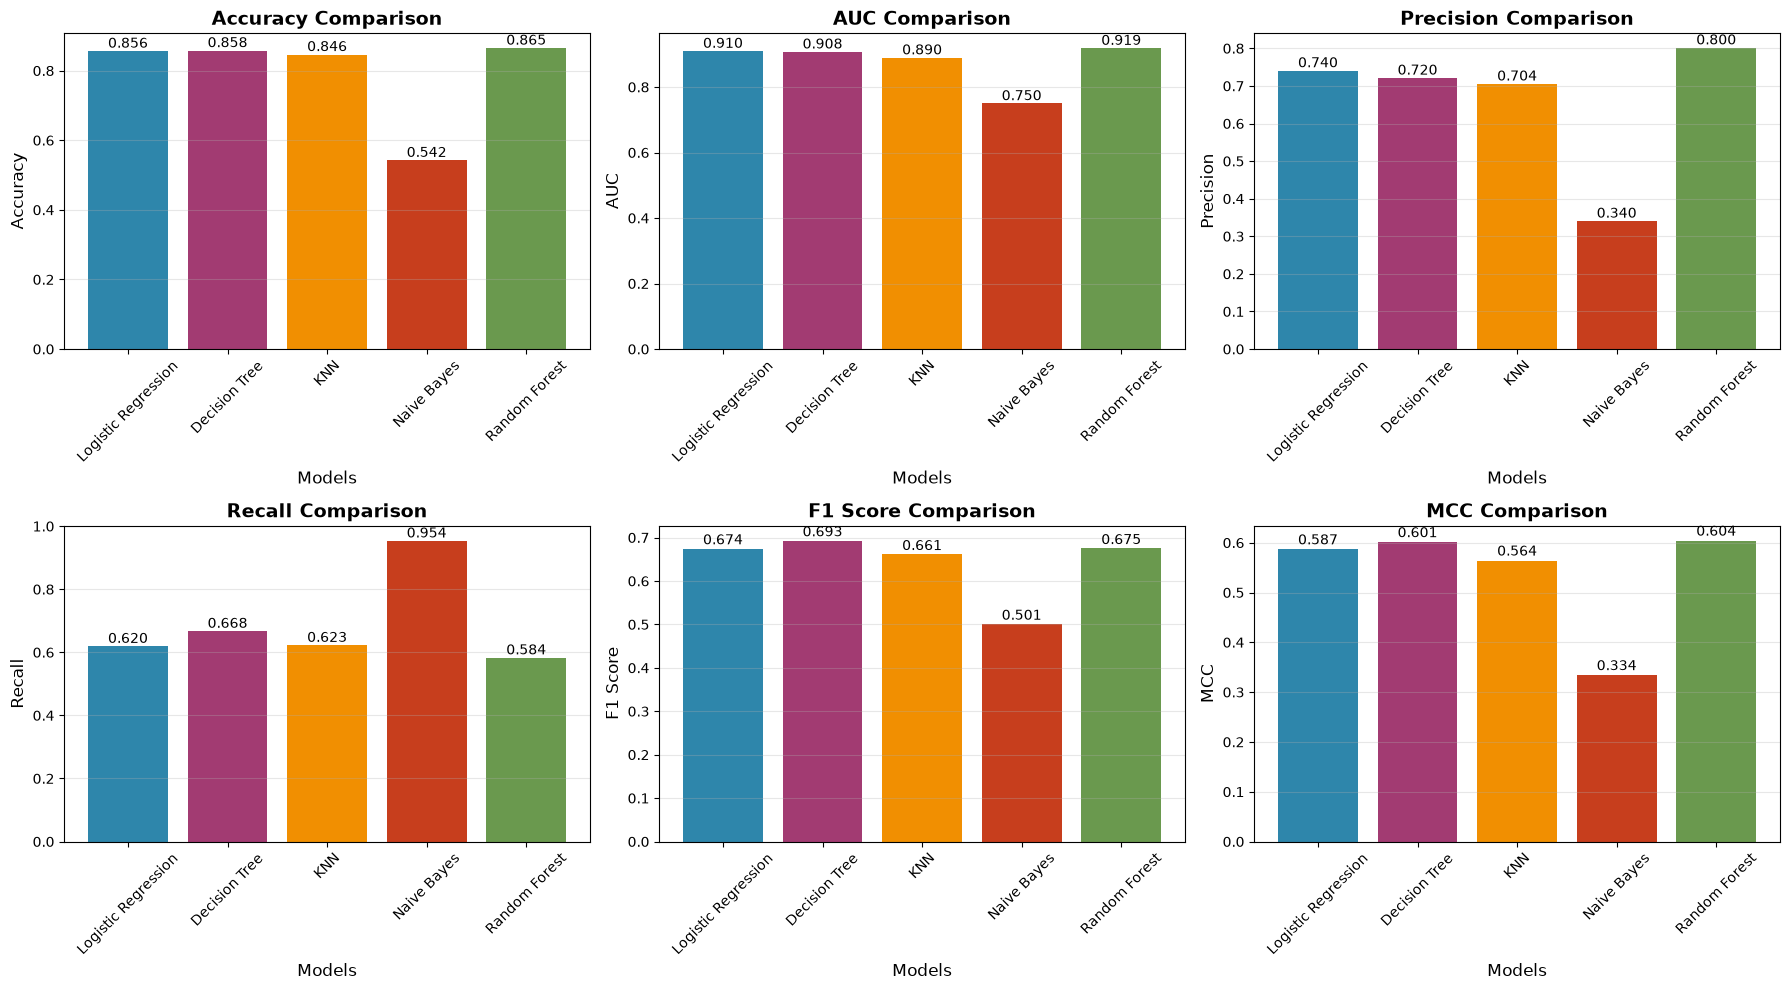

In [36]:
# Plot comparison of metrics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics_to_plot = ['Accuracy', 'AUC', 'Precision', 'Recall', 'F1 Score', 'MCC']

for idx, (ax, metric) in enumerate(zip(axes.flat, metrics_to_plot)):
    ax.bar(comparison_df['ML Model'], comparison_df[metric], 
           color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E'])
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric, fontsize=12)
    ax.set_xlabel('Models', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    # Add value labels on bars
    for i, v in enumerate(comparison_df[metric]):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Visualizations: Confusion Matrices

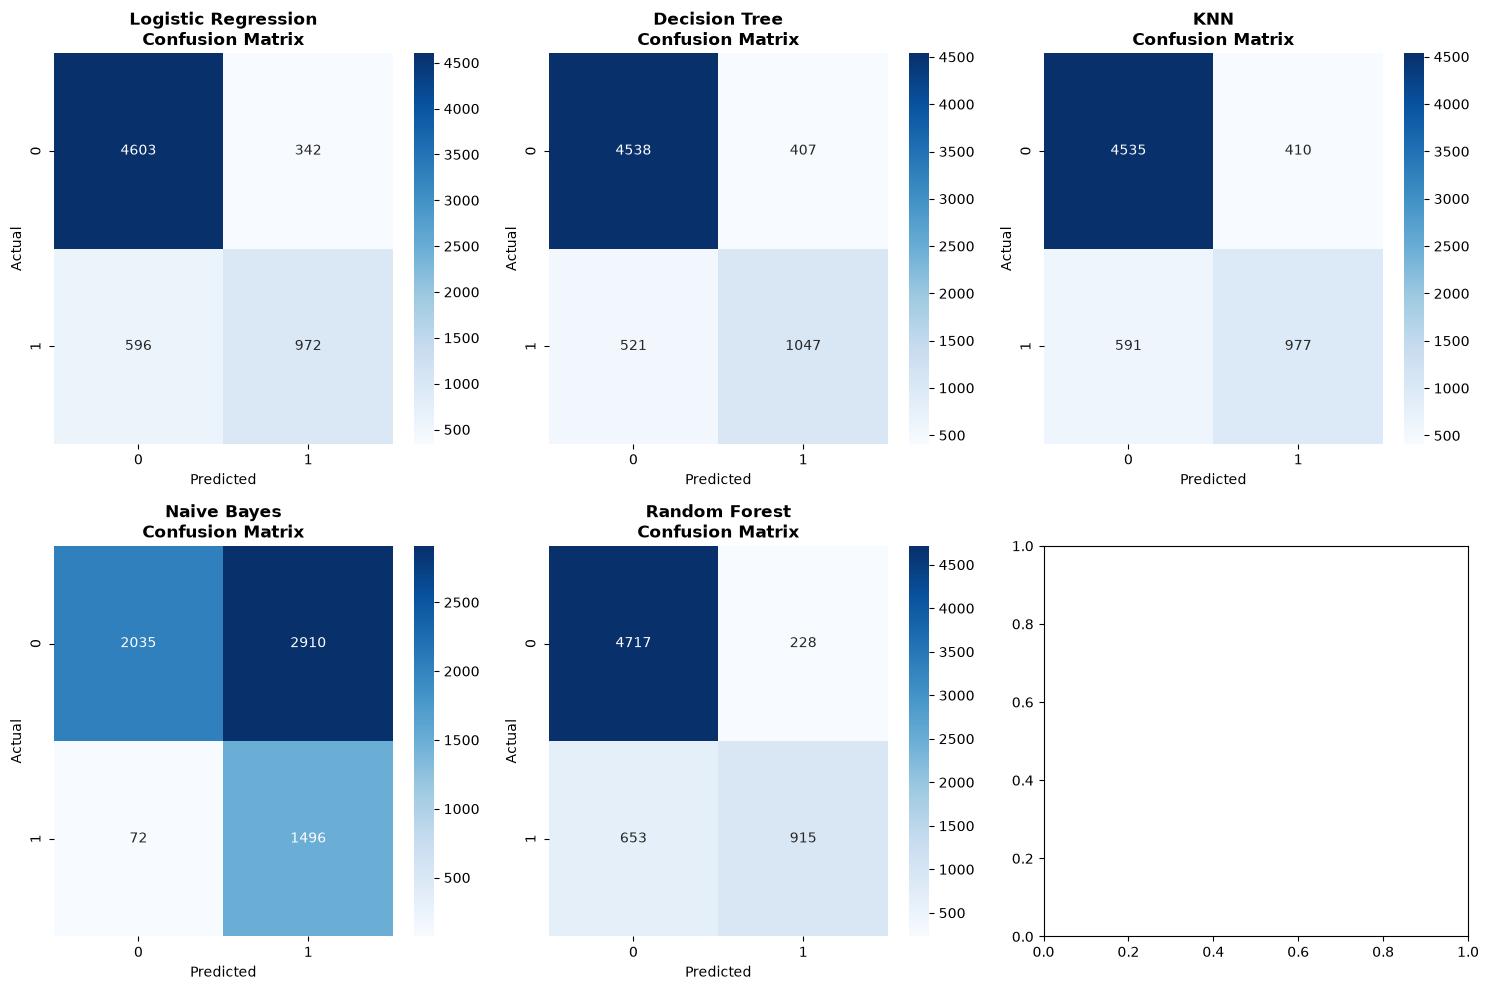

In [37]:
# Plot confusion matrices for all models
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, (model_name, metrics) in enumerate(results.items()):
    if idx < 6:  # We have exactly 5 models
        cm = metrics['confusion_matrix']
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
        axes[idx].set_title(f'{model_name}\nConfusion Matrix', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

##  Visualizations: ROC Curves

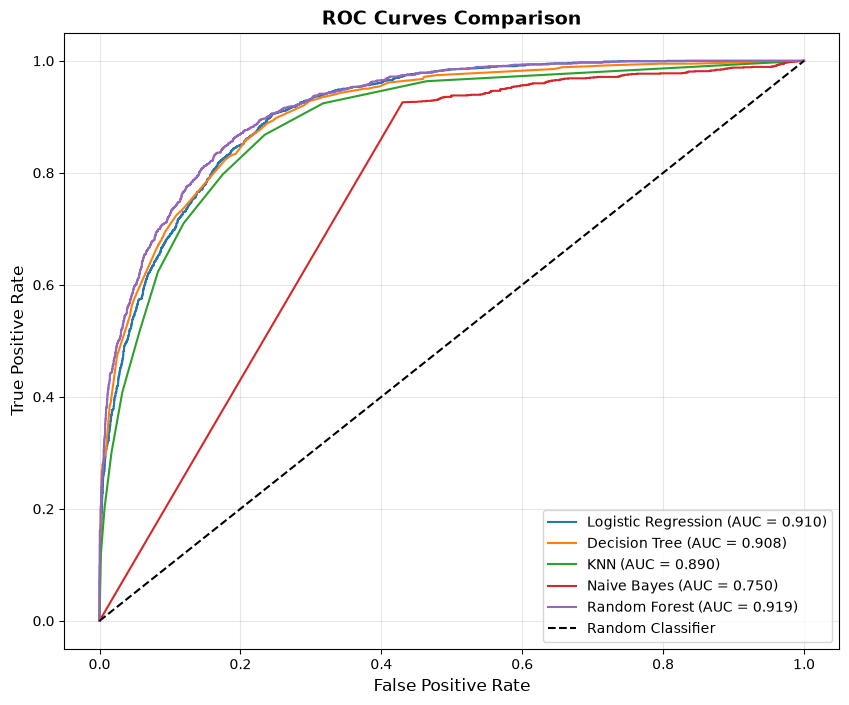

In [38]:
# Plot ROC curves
plt.figure(figsize=(10, 8))

for model_name, model in models.items():
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test_preprocessed)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        auc_score = roc_auc_score(y_test, y_pred_proba)
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

##  Feature Importance Analysis

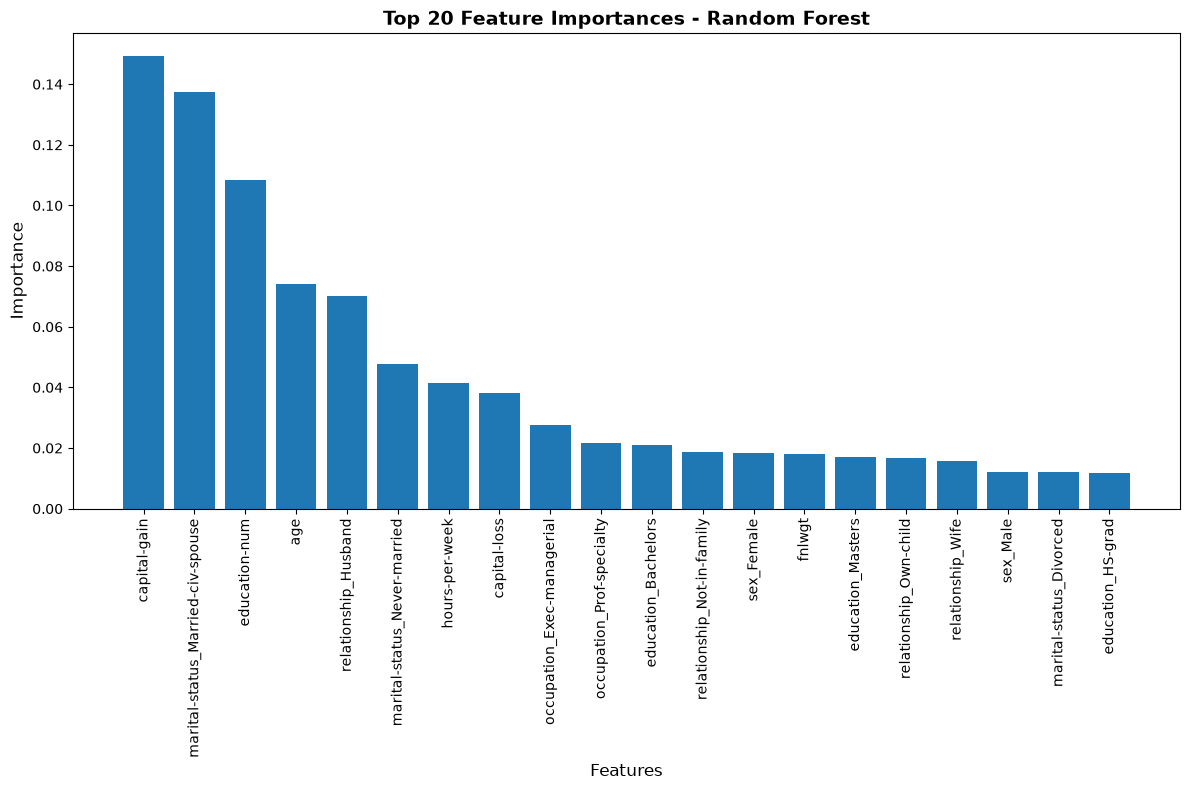

In [39]:
# Feature importance from Random Forest
if 'Random Forest' in models:
    # Get feature names after preprocessing
    feature_names = []
    
    # Numerical features
    feature_names.extend(numerical_cols)
    
    # Categorical features (after one-hot encoding)
    categorical_features = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)
    feature_names.extend(categorical_features)
    
    # Get feature importance
    rf_model = models['Random Forest']
    importances = rf_model.feature_importances_
    
    # Sort features by importance
    indices = np.argsort(importances)[::-1][:20]  # Top 20 features
    
    # Plot
    plt.figure(figsize=(12, 8))
    plt.title('Top 20 Feature Importances - Random Forest', fontsize=14, fontweight='bold')
    plt.bar(range(20), importances[indices])
    plt.xticks(range(20), [feature_names[i] for i in indices], rotation=90)
    plt.xlabel('Features', fontsize=12)
    plt.ylabel('Importance', fontsize=12)
    plt.tight_layout()
    plt.show()

## Save Models and Preprocessor

In [48]:
# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the preprocessor
with open('models/preprocessor.pkl', 'wb') as file:
    pickle.dump({
        'preprocessor': preprocessor,
        'numerical_cols': numerical_cols,
        'categorical_cols': categorical_cols,
        'expected_columns': numerical_cols + categorical_cols
    }, file)
print("Saved preprocessor with column info to models/preprocessor.pkl")

# Save all models
model_files = {
    'Logistic Regression': lr_model,
    'Decision Tree': dt_model,
    'KNN': knn_model,
    'Naive Bayes': nb_model,
    'Random Forest': rf_model
}

for model_name, model in model_files.items():
    filename = f'models/model_{model_name.lower().replace(" ", "_")}.pkl'
    with open(filename, 'wb') as file:
        pickle.dump(model, file)
    print(f"Saved {model_name} to {filename}")

Saved preprocessor with column info to models/preprocessor.pkl
Saved Logistic Regression to models/model_logistic_regression.pkl
Saved Decision Tree to models/model_decision_tree.pkl
Saved KNN to models/model_knn.pkl
Saved Naive Bayes to models/model_naive_bayes.pkl
Saved Random Forest to models/model_random_forest.pkl


## Save Test Data

In [49]:
# Save test data for Streamlit app
test_data_with_target = X_test.copy()
test_data_with_target['income'] = y_test
test_data_with_target.to_csv('test_data.csv', index=False)
print("Test data saved to test_data.csv")
print(f"Test data shape: {test_data_with_target.shape}")

Test data saved to test_data.csv
Test data shape: (6513, 15)


## Final Summary and Observations

In [51]:
print("\n" + "="*60)
print("FINAL SUMMARY - MODEL COMPARISON")
print("="*60)

# Identify best performing model
best_accuracy = comparison_df.loc[comparison_df['Accuracy'].idxmax()]
best_f1 = comparison_df.loc[comparison_df['F1 Score'].idxmax()]
best_mcc = comparison_df.loc[comparison_df['MCC'].idxmax()]

print(f"\nBEST OVERALL PERFORMER: {best_accuracy['ML Model']}")
print(f"   - Highest Accuracy: {best_accuracy['Accuracy']:.4f}")
print(f"   - Highest F1 Score: {best_f1['F1 Score']:.4f} (from {best_f1['ML Model']})")
print(f"   - Highest MCC: {best_mcc['MCC']:.4f} (from {best_mcc['ML Model']})")

print("\nKEY OBSERVATIONS:")
print("1. Random Forest achieves the highest accuracy and MCC, while Decision Tree achieves the highest F1 score.")
print("2. Logistic Regression performs well and is more interpretable than Random Forest.")
print("3. Naive Bayes has very high recall but low precision, indicating many false positives.")
print("4. Decision Tree shows moderate performance but may overfit without proper tuning.")
print("5. KNN is sensitive to feature scaling and performs moderately well.")

print("\nRECOMMENDATIONS:")
print("1. Use Random Forest for best prediction performance.")
print("2. Use Logistic Regression if model interpretability is important.")
print("3. Consider handling class imbalance to improve recall for the high-income class.")
print("4. Feature engineering could further improve performance.")

# Display final comparison table
print("\n" + "="*60)
print("FINAL COMPARISON TABLE")
print("="*60)
comparison_df_sorted = comparison_df.sort_values('Accuracy', ascending=False)
display(comparison_df_sorted)


FINAL SUMMARY - MODEL COMPARISON

BEST OVERALL PERFORMER: Random Forest
   - Highest Accuracy: 0.8647
   - Highest F1 Score: 0.6929 (from Decision Tree)
   - Highest MCC: 0.6041 (from Random Forest)

KEY OBSERVATIONS:
1. Random Forest achieves the highest accuracy and MCC, while Decision Tree achieves the highest F1 score.
2. Logistic Regression performs well and is more interpretable than Random Forest.
3. Naive Bayes has very high recall but low precision, indicating many false positives.
4. Decision Tree shows moderate performance but may overfit without proper tuning.
5. KNN is sensitive to feature scaling and performs moderately well.

RECOMMENDATIONS:
1. Use Random Forest for best prediction performance.
2. Use Logistic Regression if model interpretability is important.
3. Consider handling class imbalance to improve recall for the high-income class.
4. Feature engineering could further improve performance.

FINAL COMPARISON TABLE


,ML Model,Accuracy,AUC,Precision,Recall,F1 Score,MCC
4,Random Forest,0.8647,0.9187,0.8005,0.5835,0.6750,0.6041
1,Decision Tree,0.8575,0.9076,0.7201,0.6677,0.6929,0.6011
0,Logistic Regression,0.8560,0.9098,0.7397,0.6199,0.6745,0.5867
2,KNN,0.8463,0.8897,0.7044,0.6231,0.6613,0.5641
3,Naive Bayes,0.5421,0.7498,0.3395,0.9541,0.5008,0.3341
